<a href="https://colab.research.google.com/github/amir-asari/SEBB4083-Assignment2025/blob/main/MiniProject__G3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Mini Project 2025 (Pain Facial Expression Detection)


### Total marks: 15 Marks

### Group No.: 3

###Group Members:
1) CHU CHEA YIE (A22EB0019)

2) MIMI AIDILIA IZDIHAR BINTI KHAIRURRIZAL (A22EB0043)

3) MUHAMMAD DANIALHAFIZI BIN ROS AZMI (A22EB0047)

4) NUR FATIN NADHIRAH BINTI AZHAR (A22EB0065)

5) YOUSSEF HAITHAM SAYED ABDELRAZEK (A22EB0008)


## Chapter 1: Introduction

Properly measuring pain is a very important part of healthcare, especially for patients who cannot talk, such as very young babies or elderly people with dementia. Because these patients cannot explain how they feel, medical staff must look at their faces to understand their pain level. However, it is very hard to get enough real photos of patients to train an artificial intelligence because of privacy laws and ethical rules. To solve this problem, researchers have started using synthetic data, which are images of human faces created by computers. This project uses the SynPAIN (2025) research to build a system that can automatically tell the difference between "Pain" and "No Pain" using these AI-generated images.

###1.1 Background of study and related works

The primary motivation for this study is the challenge of acquiring diverse, privacy-compliant medical data. As noted by Taati et al. (2025), synthetic datasets like SynPAIN offer a viable alternative by generating high-fidelity facial expressions without compromising patient privacy. In the domain of pain assessment, traditional datasets are often small, biased, or restricted due to ethical concerns. As highlighted in a recent review by Baku (2025), the use of synthetic data has emerged as a transformative solution in healthcare AI. Baku notes that synthetic datasets can replicate the statistical properties of real patient data—such as facial micro-expressions associated with pain—while completely eliminating the risk of re-identification or privacy breaches. This supports the finding by Taati et al. (2025) that synthetic datasets like SynPAIN offer a scalable alternative to real-world data collection.


For the classification task, this project employs Transfer Learning using the Inception V3 architecture. Originally proposed by Szegedy et al. (2016), Inception V3 is a Convolutional Neural Network (CNN) pre-trained on millions of images from ImageNet, making it highly effective for feature extraction in tasks with limited training data. This methodology aligns with recent advancements in the field, such as the "DeepPain" framework developed by Rodriguez et al. (2017). Their research demonstrated that deep learning models can automatically learn complex facial features associated with pain directly from pixels, often outperforming traditional manual coding methods. By leveraging synthetic data, this project aims to apply these modern architectural strengths to detect pain cues in non-verbal subjects effectively.

###1.2 Objectives

The main goals of this project are as follows:



1.  To develop an automated pain detection system using the Inception V3 model and the SynPAIN synthetic dataset.
2.   To analyze how different data splitting ratios, such as 70:30, 80:20, and 90:10, change the accuracy and loss results.
3. To evaluate the impact of data augmentation, specifically rotation, zoom, and flipping, on the performance of the model.
4. To investigate how changing the learning rate between high, standard, and low values affects the training stability and final accuracy.

# Chapter 2: Methodology and Results

### 2.1 Data Loading and Visualization


The first stage of our project is to prepare the synthetic dataset for the Inception V3 model. We use the SynPAIN dataset, which contains high-quality images of human faces already resized to *299 x 299*  pixels to fit the memory limits of Google Colab. We use the gdown command to download the dataset zip file directly from Google Drive. After downloading the file, we use the zipfile and shutil libraries to extract the data into the local folder. To make sure the code is reliable and works well, our script includes an automatic folder search that scans the directory to find the "Pain" and "No_Pain" classes, even if the files are stored in sub-folders.

To verify that the labels are correct and the data loading is successful, we use ImageDataGenerator with a simple *1/255* rescaling for visualization. We generated a *3 x 3* grid of random images from both classes to look at the dataset carefully. This visualization step confirms that the "pain" and "no_pain" labels match the facial expressions before we begin the training process. This working data setup serves as the foundation for all our experiments.

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1aSs7f0WmEEpVMJlM3eSGA4FhssGHiNxW
From (redirected): https://drive.google.com/uc?id=1aSs7f0WmEEpVMJlM3eSGA4FhssGHiNxW&confirm=t&uuid=7bbba3d2-a761-46bb-bfed-508d815a3451
To: /content/SynPAIN_Dataset.zip
100% 73.0M/73.0M [00:01<00:00, 57.5MB/s]
Extracting dataset...
Extraction Complete.
Data directory located at: /content/dataset/SynPain_Resized
Contents: ['Pain', 'NoPain']
Found 5355 images belonging to 2 classes.
Success! Found 5355 images belonging to 2 classes.


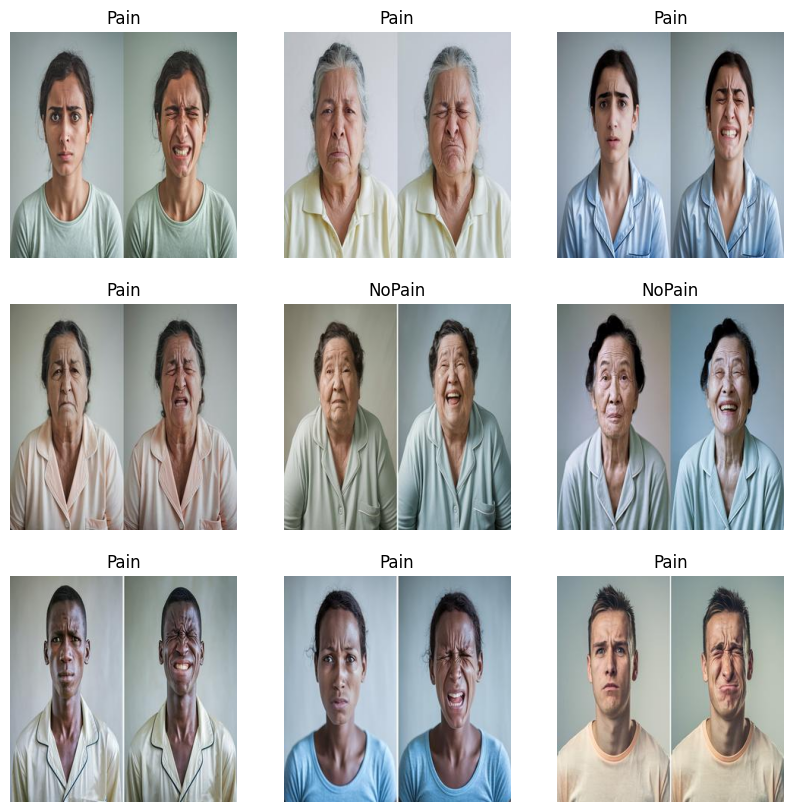

In [ ]:
# --- STEP 1: LOADED DATA & VISUALIZATION ---

import os
import zipfile
import shutil
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.inception_v3 import preprocess_input

# 1. Download the Dataset using gdown from Google Drive
!gdown --id 1aSs7f0WmEEpVMJlM3eSGA4FhssGHiNxW -O /content/SynPAIN_Dataset.zip

# 2. Extract the Zip File
zip_path = '/content/SynPAIN_Dataset.zip'
extract_path = '/content/dataset'

# Clean up previous extraction if it exists
if os.path.exists(extract_path):
    shutil.rmtree(extract_path)

print("Extracting dataset...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Extraction Complete.")

# 3. Verify Folder Structure and find the correct base directory.
base_dir = extract_path
# If the zip extracted into a subfolder
for root, dirs, files in os.walk(extract_path):
    if 'pain' in dirs or 'Pain' in dirs: # Check for folder name
        base_dir = root
        break

print(f"Data directory located at: {base_dir}")
print("Contents:", os.listdir(base_dir))

# 4. Visualization
vis_datagen = ImageDataGenerator(rescale=1./255) # Simple scaling for display

vis_generator = vis_datagen.flow_from_directory(
    base_dir,
    target_size=(299, 299), # Inception V3 Native Size
    batch_size=9,
    class_mode='binary',
    shuffle=True
)

# Check if we found the images
if vis_generator.samples == 0:
    print("ERROR: No images found. Check the folder names inside /content/dataset")
else:
    print(f"Success! Found {vis_generator.samples} images belonging to {vis_generator.num_classes} classes.")

# Plot 3x3 Grid
imgs, labels = next(vis_generator)
class_names = list(vis_generator.class_indices.keys()) # Get names like 'pain', 'no_pain'

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(imgs[i])
    # Map 0/1 label back to string
    label_name = class_names[int(labels[i])]
    plt.title(label_name)
    plt.axis('off')
plt.show()

### 2.2 Pre-Processing & Model Architecture

The primary purpose of this step was to prepare the raw data before further optimization can occur by establishing a reliable baseline for the Automated Pain Detection system. The data pre-processing step is constructed using the Keras ImageDataGenerator, designed to adapt and match the raw SynPAIN images within the InceptionV3 architecture.


1. Normalization: The preprocessing_function=preprocess_input is applied to every image. This scales the intensity of pixels to the range [-1, 1].
2. Then, the input images are resizd to 299 x 299 pixels (IMG_SIZE) to preserve the spatial resolution required by the Inception blocks when detecting facial expressions (Latif et al., 2025).
3. The training data is processed in batch size of 32, with [shuffle=True] enabling the training data to shuffle the order of images instead of memorizing it, while the [shuffle=false] ensures the validation data is able to produce consistent evluation metrics.  
4. Next, the InceptionV3 model is introduced with its weights pre-trained on ImageNet (Latif et al., 2025).
5. A GlobalAveragePooling2D layer is used to flatten the 3D feature into a 1D vector to reduce the number of parameters and prevent overfitting. A fully connected layer with 1024 neurons and ReLU  allows the model to learn high-level combinations of the extracted features (Latif et al., 2025).
6. The model was then compiled and sucessfully defined.


In [ ]:
# --- STEP 2: PREPROCESSING & MODEL ARCHITECTURE ---

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras import layers, models, optimizers

# 1. Configuration
BASE_DIR = base_dir
IMG_SIZE = (299, 299)  # Inception V3 Native Size
BATCH_SIZE = 32

# 2. Data Generators
# Use 'preprocess_input' to scale pixels between -1 and 1
print("Setting up Data Generators with InceptionV3 preprocessing...")

# Define a function to get generators so we can reuse it for Experiments A, B, C
def get_data_generators(split_ratio, augment=False):
    if augment:
        # For Experiment B
        datagen = ImageDataGenerator(
            preprocessing_function=preprocess_input,
            validation_split=split_ratio,
            rotation_range=20,     # Rotate
            zoom_range=0.2,        # Zoom
            horizontal_flip=True,  # Flip
            fill_mode='nearest'
        )
    else:
        # For Experiment A
        datagen = ImageDataGenerator(
            preprocessing_function=preprocess_input,
            validation_split=split_ratio
        )

    # Training Generator
    train_gen = datagen.flow_from_directory(
        BASE_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',   # 'Pain' vs 'NoPain'
        subset='training',
        shuffle=True
    )

    # Validation Generator
    # Use a separate non-augmented datagen for validation to be scientifically accurate
    val_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        validation_split=split_ratio
    )

    val_gen = val_datagen.flow_from_directory(
        BASE_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        subset='validation',
        shuffle=False
    )

    return train_gen, val_gen

# 3. Build Model Function
# Architecture: Inception V3
def build_inception_model(learning_rate=0.001):

    # Load InceptionV3 with ImageNet weights, excluding the top (classification) layers
    base_model = InceptionV3(
        weights='imagenet',
        include_top=False,
        input_shape=(299, 299, 3)
    )

    # Freeze the base model layers
    base_model.trainable = False

    # Add custom classification head
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(1024, activation='relu'),
        layers.Dropout(0.5), # Regularization to prevent overfitting
        layers.Dense(1, activation='sigmoid') # Binary output: 0=NoPain, 1=Pain
    ])

    # Compile the model
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

print("Model architecture defined successfully.")

Setting up Data Generators with InceptionV3 preprocessing...
Model architecture defined successfully.


### 2.3 Experiment A: Effect of Data Splitting

**Experimental Setup**

This experiment investigates the impact of the Train-Test Ratio on
model generalization and performance, to identify the most accurate split for the model.

To ensure a fair comparison, all other hyperparameters were kept fixed:
1. Learning Rate: Fixed at 0.001.
2. Epochs: Set to 8 for all runs.
3. Data Augmentation: Disabled  to isolate the effect of dataset size.

**Splitting Ratio Setup**

The dataset was split into three ratios:
1. 70:30 (70% Training / 30% Validation)
2. 80:20 (80% Training / 20% Validation)
3. 90:10 (90% Training / 10% Validation)

**Training Procedure**

1. Three distinct split ratios were defined for testing: 70:30 (0.3 split), 80:20 (0.2 split), and 90:10 (0.1 split).

2. A for loop runs the training process three separate times, once for each split ratio. Inside the loop, the following actions occurred for every ratio:
- The get_data_generators() function created new Training and Validation iterations based on the specific split percentage.

- A fresh InceptionV3 model was built (build_inception_model) to ensure that weights from previous splits did not carry over.

- The model was trained for 8 Epochs using the standard Learning Rate of 0.001.

- The training history (Accuracy and Loss metrics for both Training and Validation sets) was stored in a dictionary (history_exp_a) for comparative analysis.

3. After all three loops completed, the stored metrics were plotted on shared axes (validation accuracy over epoch graph, validation loss over epoch graph) to visualize the convergence stability and generalization of each ratio side-by-side.

- Validation accuracy: measures the percentage of predictions the model got correct on the validation set (unseen data)
- Validation Loss: measures how far off the model's probability predictions are from the actual labels

Starting Experiment A: Effect of Data Splitting...
------------------------------------------------

Running Split: 70:30 (Train: 70% / Test: 30%)
Found 3750 images belonging to 2 classes.
Found 1605 images belonging to 2 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/8


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


118/118 ━━━━━━━━━━━━━━━━━━━━ 60s 345ms/step - accuracy: 0.6309 - loss: 0.7244 - val_accuracy: 0.7383 - val_loss: 0.5178
Epoch 2/8
118/118 ━━━━━━━━━━━━━━━━━━━━ 21s 175ms/step - accuracy: 0.7769 - loss: 0.4604 - val_accuracy: 0.7047 - val_loss: 0.5966
Epoch 3/8
118/118 ━━━━━━━━━━━━━━━━━━━━ 20s 168ms/step - accuracy: 0.8372 - loss: 0.3897 - val_accuracy: 0.7520 - val_loss: 0.5189
Epoch 4/8
118/118 ━━━━━━━━━━━━━━━━━━━━ 20s 169ms/step - accuracy: 0.8545 - loss: 0.3354 - val_accuracy: 0.7738 - val_loss: 0.4695
Epoch 5/8
118/118 ━━━━━━━━━━━━━━━━━━━━ 20s 168ms/step - accuracy: 0.8546 - loss: 0.3254 - val_accuracy: 0.7745 - val_loss: 0.4896
Epoch 6/8
118/118 ━━━━━━━━━━━━━━━━━━━━ 20s 171ms/step - accuracy: 0.8671 - loss: 0.3132 - val_accuracy: 0.8162 - val_loss: 0.3946
Epoch 7/8
118/118 ━━━━━━━━━━━━━━━━━━━━ 20s 170ms/step - accuracy: 0.8815 - loss: 0.2799 - val_accuracy: 0.8112 - val_loss: 0.4201
Epoch 8/8
118/118 ━━━━━━━━━━━━━━━━━━━━ 20s 169ms/step - accuracy: 0.8820 - loss: 0.2712 - val_accura

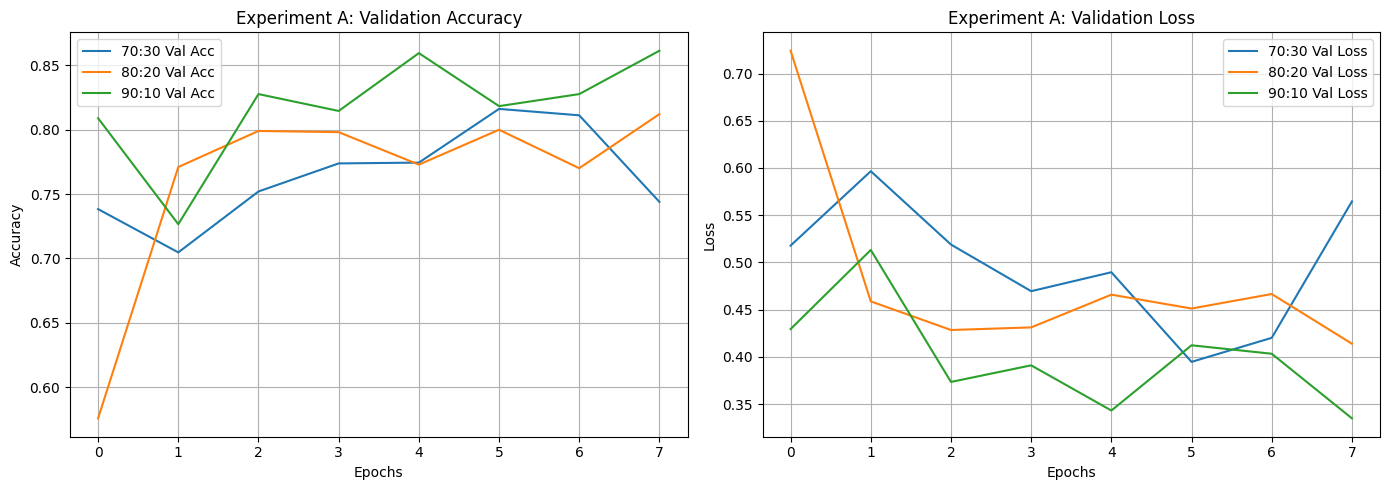

In [ ]:
# --- EXPERIMENT A ---
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras import layers, models, optimizers

# 1. RE-DEFINE THE MODEL FUNCTION
def build_inception_model(learning_rate=0.001):
    # Load InceptionV3 with ImageNet weights
    base_model = InceptionV3(
        weights='imagenet',
        include_top=False,
        input_shape=(299, 299, 3)
    )
    base_model.trainable = False  # Freeze base layers

    # Add custom classification head
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(1024, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# 2. RUN EXPERIMENT A
split_ratios = [0.3, 0.2, 0.1]
split_names = ["70:30", "80:20", "90:10"]
history_exp_a = {}
results_table = []

print("Starting Experiment A: Effect of Data Splitting...")
print("------------------------------------------------")

for i, split in enumerate(split_ratios):
    ratio_name = split_names[i]
    print(f"\nRunning Split: {ratio_name} (Train: {int((1-split)*100)}% / Test: {int(split*100)}%)")

    # Get Data
    train_gen, val_gen = get_data_generators(split_ratio=split, augment=False)

    # Build Model
    model = build_inception_model(learning_rate=0.001)

    # Train
    history = model.fit(
        train_gen,
        epochs=8,
        validation_data=val_gen,
        verbose=1
    )

    # Store Results
    history_exp_a[ratio_name] = history.history

    # Add to Table
    results_table.append({
        "Split Ratio": ratio_name,
        "Train Acc": round(history.history['accuracy'][-1], 4),
        "Val Acc": round(history.history['val_accuracy'][-1], 4),
        "Train Loss": round(history.history['loss'][-1], 4),
        "Val Loss": round(history.history['val_loss'][-1], 4)
    })

print("\nExperiment A Completed.")

# 3. VISUALIZATION
df_results = pd.DataFrame(results_table)
print("\n--- Experiment A Results Table ---")
print(df_results)

plt.figure(figsize=(14, 5))
# Plot Accuracy
plt.subplot(1, 2, 1)
for name, hist in history_exp_a.items():
    plt.plot(hist['val_accuracy'], label=f'{name} Val Acc')
plt.title('Experiment A: Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
for name, hist in history_exp_a.items():
    plt.plot(hist['val_loss'], label=f'{name} Val Loss')
plt.title('Experiment A: Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**RESULTS:**

Result table shows that:

1. The 90:10 split achieved the highest validation accuracy (86.14\%) and the lowest validation loss (0.3348).
2. The 70:30 split could suggest an overfitting because, while the training accuracy (87.95\%) is similar to other splits, the validation accuracy significantly drops to (74.39%).
3. The large gap between training and validation metrics suggests the model memorized the training data but failed to generalize to the larger, unseen test databases.

The graph visualizes the entire training data process over 8 epochs for the three splits show that:

1. Validation Accuracy: The Green Line (90:10) almost consistently maintains highest positions compared to the others. The Blue Line (70:30) drops significantly towards the end, representing non-ideal result when introduced to new unseen data.
2.  Validation Loss: The Green Line (90:10) shows a continuous decrease, indicating stable convergence. The Blue Line (70:30) displays an uncharacteristic sudden sharp spike in loss at Epoch 7, which could be an indicator of overfitting where the model begins to memorize training data at but actually producing low validation performance.

### 2.4 Experiment B: Effect of Data Augmentation

**Experimental Setup**

1)To isolate the effect of data augmentation on model performance, the data split was fixed at 80:20 using `FIXED_SPLIT = 0.2`
, where 80% of the data was used for training and 20% for validation.



Fixing the split ensures that any performance difference is caused only by data augmentation, not by changes in data distribution.


**Data Augmentation Setup**

Two training conditions were evaluated:

**Case 1: Without Data Augmentation**


In this condition, the training and validation images were only preprocessed without any augmentation.
An `ImageDataGenerator` was used with `preprocessing_function=preprocess_input`, allowing the model to learn from the original dataset without artificial variations.

**Case 2: With Data Augmentation**

In this condition, data augmentation was applied only to the training set using the following techniques:

1) `rotation_range=10`  to simulate slight head tilts.

2) `zoom_range=0.1` to account for variations in face distance.   

3) `horizontal_flip=True` to improve robustness to left–right facial orientation.

The augmentation parameters were selected in accordance with the settings reported by Lahari et al. (2023) for facial emotion classification.

**Training Procedure**

1)Two models were trained:

*   Without data augmentation
*   With data augmentation (rotation, zoom, and horizontal flip)


2)Validation accuracy and validation loss were recorded after each epoch.


*   Higher validation accuracy means the model is making more correct predictions.
*   Lower validation loss means the model is making fewer mistakes and learning more stably.



3)Final results were summarized in a table, and accuracy and loss graphs were plotted to compare performance.



Starting Experiment B: Effect of Data Augmentation...
Fixed Split: 80:20 (Validation Split = 0.2)
------------------------------------------------

Running Case 1: WITHOUT Augmentation...
Found 4285 images belonging to 2 classes.
Found 1070 images belonging to 2 classes.
Epoch 1/8


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


134/134 ━━━━━━━━━━━━━━━━━━━━ 50s 275ms/step - accuracy: 0.6238 - loss: 0.8427 - val_accuracy: 0.6579 - val_loss: 0.6210
Epoch 2/8
134/134 ━━━━━━━━━━━━━━━━━━━━ 20s 151ms/step - accuracy: 0.7879 - loss: 0.4375 - val_accuracy: 0.5682 - val_loss: 0.8984
Epoch 3/8
134/134 ━━━━━━━━━━━━━━━━━━━━ 20s 151ms/step - accuracy: 0.7961 - loss: 0.4367 - val_accuracy: 0.7598 - val_loss: 0.4812
Epoch 4/8
134/134 ━━━━━━━━━━━━━━━━━━━━ 20s 148ms/step - accuracy: 0.8322 - loss: 0.3595 - val_accuracy: 0.7458 - val_loss: 0.5416
Epoch 5/8
134/134 ━━━━━━━━━━━━━━━━━━━━ 20s 148ms/step - accuracy: 0.8678 - loss: 0.3210 - val_accuracy: 0.7822 - val_loss: 0.4669
Epoch 6/8
134/134 ━━━━━━━━━━━━━━━━━━━━ 20s 152ms/step - accuracy: 0.8417 - loss: 0.3591 - val_accuracy: 0.7869 - val_loss: 0.4400
Epoch 7/8
134/134 ━━━━━━━━━━━━━━━━━━━━ 20s 151ms/step - accuracy: 0.8761 - loss: 0.2876 - val_accuracy: 0.8037 - val_loss: 0.4231
Epoch 8/8
134/134 ━━━━━━━━━━━━━━━━━━━━ 20s 147ms/step - accuracy: 0.8827 - loss: 0.2761 - val_accura

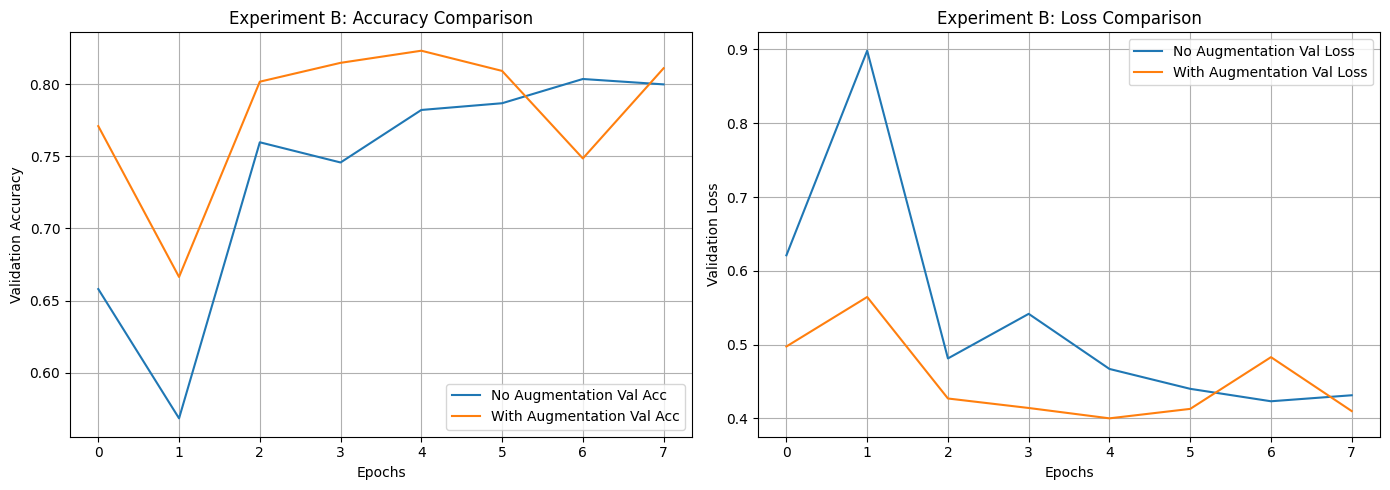

In [ ]:
# --- EXPERIMENT B ---
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.inception_v3 import preprocess_input

# 1. Configuration
FIXED_SPLIT = 0.2  # 80% Train, 20% Validation
BATCH_SIZE = 32
IMG_SIZE = (299, 299)
BASE_DIR = '/content/dataset/SynPain_Resized'

results_table_b = []
history_exp_b = {}

print("Starting Experiment B: Effect of Data Augmentation...")
print(f"Fixed Split: 80:20 (Validation Split = {FIXED_SPLIT})")
print("------------------------------------------------")

# --- CASE 1: WITHOUT AUGMENTATION ---
print("\nRunning Case 1: WITHOUT Augmentation...")

# Define Generator (Only Preprocessing)
datagen_no_aug = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=FIXED_SPLIT
)

train_gen_no = datagen_no_aug.flow_from_directory(
    BASE_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', subset='training', shuffle=True
)
val_gen_no = datagen_no_aug.flow_from_directory(
    BASE_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', subset='validation', shuffle=False
)

# Build & Train
model_no = build_inception_model(learning_rate=0.001)
hist_no = model_no.fit(train_gen_no, epochs=8, validation_data=val_gen_no, verbose=1)

# Store Results
history_exp_b['No Augmentation'] = hist_no.history
results_table_b.append({
    "Condition": "No Augmentation",
    "Val Acc": round(hist_no.history['val_accuracy'][-1], 4),
    "Val Loss": round(hist_no.history['val_loss'][-1], 4)
})

# --- CASE 2: WITH AUGMENTATION ---
print("\nRunning Case 2: WITH Augmentation (Rotation, Zoom, Flip)...")

# Define Generator (Preprocessing + Augmentation)
datagen_aug = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=FIXED_SPLIT,
    # Facial Expression Recognition (FER) Standard Parameter
    rotation_range=10,     # Rotation
    zoom_range=0.1,        # Zoom
    horizontal_flip=True,  # Flip
    fill_mode='nearest'
)

train_gen_aug = datagen_aug.flow_from_directory(
    BASE_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', subset='training', shuffle=True
)
# Validation data is NEVER augmented, only preprocessed.
# Reuse val_gen_no for fair comparison.

# Build & Train
model_aug = build_inception_model(learning_rate=0.001)
hist_aug = model_aug.fit(train_gen_aug, epochs=8, validation_data=val_gen_no, verbose=1)

# Store Results
history_exp_b['With Augmentation'] = hist_aug.history
results_table_b.append({
    "Condition": "With Augmentation",
    "Val Acc": round(hist_aug.history['val_accuracy'][-1], 4),
    "Val Loss": round(hist_aug.history['val_loss'][-1], 4)
})

print("\nExperiment B Completed.")

# --- RESULTS VISUALIZATION ---
df_b = pd.DataFrame(results_table_b)
print("\n--- Experiment B Results Table ---")
print(df_b)

plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
for name, hist in history_exp_b.items():
    plt.plot(hist['val_accuracy'], label=f'{name} Val Acc')
plt.title('Experiment B: Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
for name, hist in history_exp_b.items():
    plt.plot(hist['val_loss'], label=f'{name} Val Loss')
plt.title('Experiment B: Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Results for Experiment B**

Result table show that:

*   Without augmentation, the model achieved a validation accuracy of 0.8000 with a validation loss of 0.4312.
*   With data augmentation, validation accuracy increased to 0.8112 and validation loss decreased to 0.4098.
*   This shows that applying rotation, zoom, and horizontal flip slightly improved model performance.

The graph visualizes the entire training data process over 8 epochs for without augmentation and with augmentation show that:
*   Validation Accuracy: The orange line (With Augmentation) consistently trends higher than the blue line (No Augmentation) throughout most of the training process.
*   Validation Loss: The blue line (No Augmentation) shows a massive spike in loss at Epoch 1 (reaching nearly 0.9).The orange line (With Augmentation) is much smoother. It completely avoided the massive error spike seen in the blue line.

###2.5 Experiment C: Effect of Learning Rate
**Experimental Setup**
1. To isolate the effect of the learning rate, the data split was fixed at 80:20 by `FIXED_SPLIT = 0.2`and Data Augmentation was enabled  (Rotation, Zoom, Flip) for training  by `augment=True` , parameter same as Experiment B.
2. The validation set was only preprocessed (using preprocess_input from InceptionV3) without augmentation `augment=False` to ensure fair evaluation .
3. The model was trained for `epochs=8` to observe short-term convergence behavior.

**Learning Rate Setup**
: Three distinct learning rates were evaluated looping through `[0.01, 0.001, 0.0001]`
1. High ($0.01$): To test for rapid convergence and stability limits.
2. Standard ($0.001$): The default configuration for the Adam optimizer (Kingma & Ba,2015).
3. Low ($0.0001$): To test for fine-grained weight adjustments suitable for Transfer Learning (Xu, 2022)

**Training Procedure**
1. A training loop was executed three times, once for each defined learning rate ($0.01, 0.001, 0.0001$).
2. At the start of each iteration, a fresh instance of the InceptionV3-based model was instantiated and compiled with the specific learning rate. This step ensured that weights were reset between runs, preventing previous training sessions from biasing the results of subsequent learning rates.
2. The model was trained for 8 epochs using the augmented training generator to introduce variability. Validation was performed at the end of every epoch using the non-augmented validation generator to ensure a stable performance metric.
3. The final validation accuracy and validation loss were recorded. Final performance metrics were stored in a structured table for comparative analysis.
4. Epoch-wise validation accuracy and validation loss curves were plotted to visualize learning dynamics.

Starting Experiment C: Effect of Learning Rate...
------------------------------------------------
Loading Augmented Data...
Found 4285 images belonging to 2 classes.
Found 1070 images belonging to 2 classes.

--- Running with Learning Rate: 0.01 ---
Epoch 1/8
134/134 ━━━━━━━━━━━━━━━━━━━━ 119s 790ms/step - accuracy: 0.5847 - loss: 3.6905 - val_accuracy: 0.6290 - val_loss: 0.6026
Epoch 2/8
134/134 ━━━━━━━━━━━━━━━━━━━━ 92s 684ms/step - accuracy: 0.7220 - loss: 0.5373 - val_accuracy: 0.7439 - val_loss: 0.5125
Epoch 3/8
134/134 ━━━━━━━━━━━━━━━━━━━━ 91s 677ms/step - accuracy: 0.7404 - loss: 0.5288 - val_accuracy: 0.7327 - val_loss: 0.5177
Epoch 4/8
134/134 ━━━━━━━━━━━━━━━━━━━━ 91s 676ms/step - accuracy: 0.7239 - loss: 0.5319 - val_accuracy: 0.7748 - val_loss: 0.5275
Epoch 5/8
134/134 ━━━━━━━━━━━━━━━━━━━━ 91s 675ms/step - accuracy: 0.6787 - loss: 0.5917 - val_accuracy: 0.5720 - val_loss: 0.6904
Epoch 6/8
134/134 ━━━━━━━━━━━━━━━━━━━━ 91s 676ms/step - accuracy: 0.6865 - loss: 0.5936 - val_accu

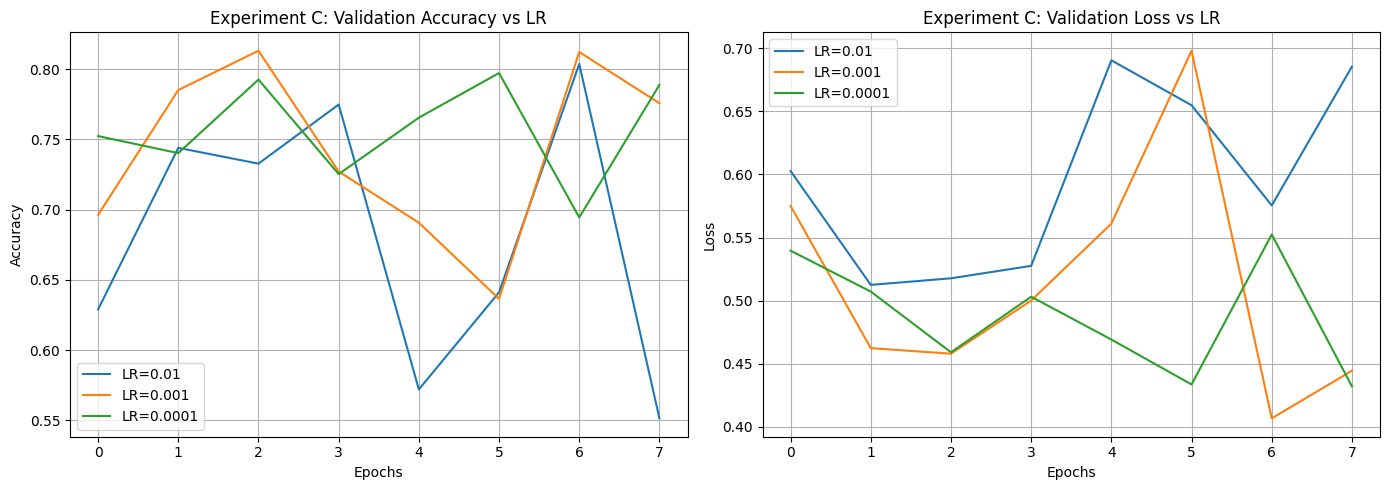

In [ ]:
# ---  EXPERIMENT C  ---
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

# 1. Configuration
# 3 speeds: High (0.01), Standard (0.001), Low (0.0001)
learning_rates = [0.01, 0.001, 0.0001]
FIXED_SPLIT = 0.2  # 80% Train, 20% Validation

history_exp_c = {}
results_table_c = []

print("Starting Experiment C: Effect of Learning Rate...")
print("------------------------------------------------")

# 2. Get Data (Augmented)
# We use the 'augment=True' generator for all runs here as per instructions
print("Loading Augmented Data...")
train_gen, val_gen = get_data_generators(split_ratio=FIXED_SPLIT, augment=True)

# 3. Loop through Learning Rates
for lr in learning_rates:
    print(f"\n--- Running with Learning Rate: {lr} ---")

    # A. Build Model with the specific LR
    # We call our builder function and pass the current 'lr'
    model = build_inception_model(learning_rate=lr)

    # B. Train
    # We use 8 epochs to keep it consistent with previous experiments
    history = model.fit(
        train_gen,
        epochs=8,
        validation_data=val_gen,
        verbose=1
    )

    # C. Store Results
    label = f"LR={lr}"
    history_exp_c[label] = history.history

    # D. Record Final Metrics
    final_acc = history.history['val_accuracy'][-1]
    final_loss = history.history['val_loss'][-1]

    results_table_c.append({
        "Learning Rate": lr,
        "Val Acc": round(final_acc, 4),
        "Val Loss": round(final_loss, 4)
    })

print("\nExperiment C Completed.")

# --- RESULTS VISUALIZATION ---
df_c = pd.DataFrame(results_table_c)
print("\n--- Experiment C Results Table ---")
print(df_c)

plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
for name, hist in history_exp_c.items():
    plt.plot(hist['val_accuracy'], label=name)
plt.title('Experiment C: Validation Accuracy vs LR')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
for name, hist in history_exp_c.items():
    plt.plot(hist['val_loss'], label=name)
plt.title('Experiment C: Validation Loss vs LR')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Result for Experiment C**

Result table shows that:

1. The highest validation accuracy was achieved with a learning rate of 0.0001 (0.7888), and the lowest with 0.01 (0.5514).
2. The lowest validation loss was also observed for 0.0001 (0.4321), and the highest loss occurred at 0.01 (0.6854).


The graph visualizes the entire training data process over 8 epochs for the three learning rate show that:
1. Validation Accuracy: The graph shows that the lowest learning rate (green line) maintains a stable high score, while the high learning rate (blue line) causes the accuracy to jump up and down unpredictably
2. Validation Loss: The graph proves that the high learning rate (blue line) causes massive error spikes， whereas the low learning rate (green line) smoothly reduces the error over time without fluctuating.

## Chapter 3: Discussion

1. **Effect of Data Splitting (Experiment A)**

The results show that the 90:10 train–test split achieved the best performance, with the highest validation accuracy of 86.14% and the lowest validation loss of 0.3348. This indicates that the model was able to learn more effectively when a larger portion of the dataset was used for training.

Although the 70:30 split achieved a high training accuracy of 87.95%, its validation accuracy dropped significantly to 74.39%. The large gap between training and validation performance suggests that the model overfitted the training data, meaning it memorized patterns instead of learning features that generalize well to unseen images. This issue is clearly reflected in the validation loss graph, where a sudden spike occurs at Epoch 7, indicating unstable learning.

From the validation accuracy graph, the 90:10 split consistently maintains the highest accuracy, while the 70:30 split drops sharply toward the end of training. This behavior shows that InceptionV3 benefits from having more training data, as its deeper layers require sufficient examples to fine-tune effectively. Overall, the 90:10 split provides the most stable convergence and best generalization performance for this task.

2. **Effect of Data Augmentation (Experiment B)**

For Experiment B, the results show that data augmentation slightly improved model performance. Without augmentation, the model achieved a validation accuracy of 0.8000 and a validation loss of 0.4312. When augmentation was applied, validation accuracy increased to 0.8112, and validation loss decreased to 0.4098.

Although the numerical improvement appears small, the training graphs reveal an important difference in training stability. The validation loss for the model trained without augmentation shows a large spike at Epoch 1, reaching nearly 0.9. This suggests that the model was highly sensitive to the limited variations in the synthetic dataset.

In contrast, the augmented model shows a much smoother loss curve and avoids the large error spike entirely. By applying rotation, zoom, and horizontal flipping, the model was forced to learn more robust and invariant facial features rather than memorizing specific synthetic patterns. This result highlights the importance of data augmentation in improving generalization, especially when working with synthetic facial expression data.

3. **Effect of Learning Rate (Experiment C)**

Experiment C demonstrates that the learning rate has a significant impact on both model accuracy and training stability. The highest validation accuracy (0.7888) and lowest validation loss (0.4321) were achieved using a learning rate of 0.0001. In contrast, the learning rate of 0.01 produced the poorest results, with a validation accuracy of only 0.5514 and the highest loss (0.6854).

From the validation accuracy graph, the lowest learning rate maintains a stable and consistently high accuracy, while the highest learning rate causes large and unpredictable fluctuations. Similarly, the validation loss graph shows that the high learning rate produces frequent error spikes, whereas the low learning rate results in a smooth and gradual reduction in loss.

These results indicate that a high learning rate causes the model to overshoot optimal weight values, preventing proper convergence. On the other hand, a low learning rate allows gradual fine-tuning of the pre-trained InceptionV3 weights, which is more suitable for transfer learning. Therefore, a conservative learning rate is essential for achieving stable and reliable performance in this task.

## Chapter 4: Conclusion

This project successfully achieved its objective of developing an automated pain detection system by fine-tuning the InceptionV3 convolutional neural network on the SynPAIN synthetic facial expression dataset. Through systematic experimentation, the effects of data splitting, data augmentation, and learning rate selection were critically analyzed.

The findings indicate that the most reliable model configuration consists of a 90:10 train–test split, the use of data augmentation, and a low learning rate of 0.0001. These settings collectively improved accuracy, reduced overfitting, and ensured stable convergence during training.

While the use of synthetic data effectively addresses privacy, ethical, and data scarcity challenges, the experiments reveal that InceptionV3 is highly sensitive to hyperparameter choices, requiring careful tuning to maintain stability and reliability. Overall, the proposed model demonstrates strong potential for identifying pain-related facial expressions in a controlled synthetic environment.

## References
1. B. Taati et al., "SynPAIN: A Synthetic Dataset of Pain and Non-Pain Facial Expressions," arXiv preprint arXiv:2507.19673, 2025.  
2. C. Shorten and T. M. Khoshgoftaar, "A survey on Image Data Augmentation for Deep Learning," J. Big Data, vol. 6, no. 1, 2019.
3. S. Baku, "Synthetic Data in AI Healthcare Research: A Review of Use Cases, Benefits, and Risks," ResearchGate, June 2025.
4. C. Szegedy et al., "Rethinking the Inception Architecture for Computer Vision," in Proc. CVPR, 2016.
5. P. Rodriguez, G. Cucurull, J. Gonzalez, and F. X. Roca, "DeepPain: Exploiting long short-term memory networks for facial expression classification," IEEE Transactions on Cybernetics, vol. 52, no. 5, pp. 3314–3324, 2017.
6. G. Bargshady et al., "The use of deep continuous local binary patterns for improved pain recognition," IEEE Access, vol. 8, 2020.
7. J. Deng et al., "ImageNet: A large-scale hierarchical image database," in Proc. CVPR, 2009.
8. Kingma, D. P., & Ba, J. (2015). Adam: A method for stochastic optimization. 3rd International Conference on Learning Representations (ICLR). https://doi.org/10.48550/arXiv.1412.6980
9. K. Simonyan and A. Zisserman, "Very Deep Convolutional Networks for Large-Scale Image Recognition," arXiv preprint arXiv:1409.1556, 2014.
10. Lahari, A. S., Supraja, M., Akshaya, C., & Reddy, K. V. (2023). Emotion classification of facial images using machine learning models. International Journal for Research in Applied Science & Engineering Technology (IJRASET), 11(4), 3203-3206. doi.org
11. Latif, A., Yuliyanti, S., & Al-Husaini, M. (2025). Braille pattern detection modeling using Inception V3 architecture using median filter implementation and segmentation. International Journal of Applied Sciences and Smart Technologies, 7(2), 417–432. https://doi.org/10.24071/ijasst.v7i2.12781
12. T. Alghamdi and G. Alaghband, “Facial Expressions Based Automatic Pain Assessment System,” Applied Sciences (Switzerland), vol. 12, no. 13, 2022, doi: 10.3390/app12136423.
13. Xu, Kaixi. (2022). Transfer Learning-based Convolutional Neural Networks in Pneumonia Recognition. Highlights in Science, Engineering and Technology. 23. 82-85. 10.54097/hset.v23i.3200.







  
